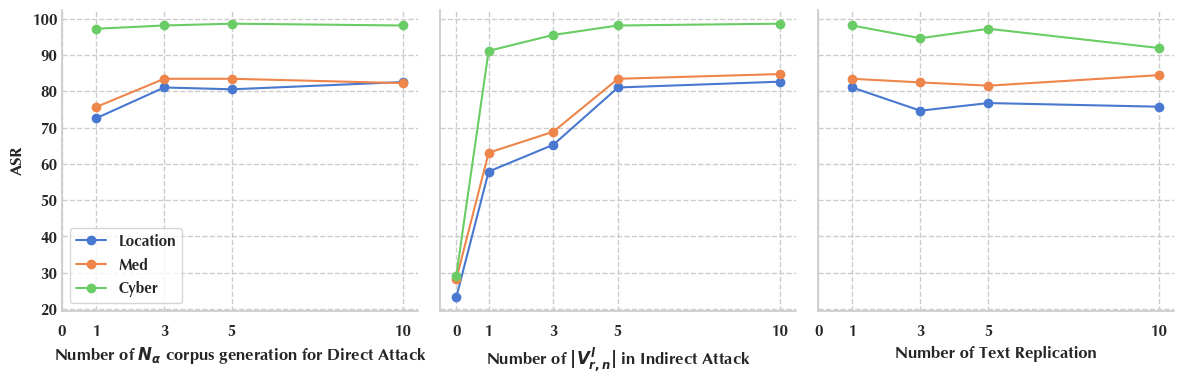

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 设置 Seaborn 风格
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Optima'
plt.rcParams['font.weight'] = 'bold'
# plt.rcParams['font.size'] = 16
# Nature 杂志风格的配色方案
colors = sns.color_palette("muted")

x = [0,1, 3, 5, 10]  # 只有四个数据点


#${{N_\alpha}}$
data1 = [[[1, 72.6], [3, 81.1], [5, 80.6], [10, 82.6]],
           [[1, 75.7], [3, 83.5], [5, 83.5], [10, 82.3]],
           [[1,97.3],[3,98.2],[5,98.7],[10,98.2]]]
# 89,87,89,92
# 86.1,86.1,84.7,88.9
# data1_prenode = [[[1,40],[3,53],[5,60]]]
#middle node$
# data2 = [[[1, 85], ,
#            [[1, 86], ]]

#$|V_{r,n}^{l}|$ enhance
data3= [[[0,23.2],[1, 57.9], [3, 65.3], [5, 81.1],[10, 82.7]],
           [[0,28.2], [1, 63.1], [3, 68.9], [5, 83.5],[10, 84.8]],
           [[0,29.2],[1,91.2],[3,95.6],[5,98.2],[10,98.7]]]


#replication
data4= [[[1, 81.1], [3, 74.7], [5, 76.8],[10,75.8]],
           [[1, 83.5], [3, 82.5], [5, 81.6],[10,84.5]],
           [[1,98.2],[3,94.7],[5,97.3],[10,92.0]]]


data_full = [data1,  data3, data4]
# 创建一个包含4个子图的图形
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)  # Use sharey=True for consistent y-axis

# 为每个子图设置不同的 x 轴标签和刻度标签
x_labels = [
    r'Number of $N_\alpha$ corpus generation for Direct Attack',
    r'Number of $|V_{r,n}^{l}|$ in Indirect Attack',
    'Number of Text Replication'
]

x_tick_labels = [
    ['0','1', '3', '5', '10'],
    ['0','1', '3', '5', '10'],
    ['0','1', '3', '5', '10'],

]



# 绘制每个子图
for i, ax in enumerate(axes):

    ax.plot([d[0] for d in data_full[i][0]], [d[1] for d in data_full[i][0]], marker='o', color=colors[0], label='geographic')
    ax.plot([d[0] for d in data_full[i][1]], [d[1] for d in data_full[i][1]], marker='o', color=colors[1], label='Med')
    ax.plot([d[0] for d in data_full[i][2]], [d[1] for d in data_full[i][2]], marker='o', color=colors[2], label='cybersecurity')
   
    ax.set_xlabel(x_labels[i],fontweight='bold')  # 设置不同的 x 轴标签
    if i == 0:
        ax.set_ylabel('ASR',fontweight='bold')  # Ensure y-axis label is set for each subplot
    ax.set_xticks(x)
    ax.set_xticklabels(x_tick_labels[i])  # 设置不同的 x 轴刻度标签
    if i == 0:
        ax.legend()
    # 添加网格线
    ax.grid(True, linestyle='--')

    # 隐藏特定的边框
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)  # 显示左边框

    # 保留 y 轴的刻度线
    ax.tick_params(axis='y', length=0)

# 调整布局
plt.tight_layout()
plt.savefig('ablation.pdf')

# 显示图形
plt.show()

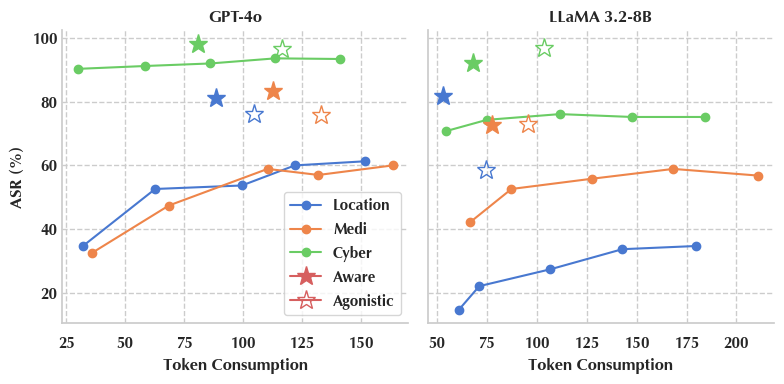

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set Seaborn style
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Optima'
plt.rcParams['font.weight'] = 'bold'

# Define colors
colors = sns.color_palette("muted")

# Data for the plots
data_default = {
    'geographic': [(32, 34.7), (62.7, 52.6), (99.6, 53.7), (122.1, 60), (152.1, 61.3)],
    'medical': [(36, 32.6), (68.5, 47.4), (110.5, 58.9), (132.1, 57), (163.7, 60)],
    'cybersecurity': [(29.8, 90.3), (58.5, 91.2), (86.2, 92.0), (113.8, 93.6), (141.3, 93.4)],
    'gray': [(88.4, 81.1), (112.6, 83.5), (81.1, 98.2)],
    'black': [(104.7, 76.1), (133, 75.8), (116.5, 96.4)]
}

data_llama = {
    'geographic': [(61.1, 14.7), (71.3, 22.1), (106.9, 27.4), (142.9, 33.7), (179.7, 34.7)],
    'medical': [(66.6, 42.1), (87.4, 52.6), (127.5, 55.8), (168.4, 58.9), (210.9, 56.8)],
    'cybersecurity': [(54.9, 70.8), (75.1, 74.3), (111.6, 76.1), (147.8, 75.2), (184.5, 75.2)],
    'gray': [(53.3, 81.7), (77.8, 72.7), (68, 92)],
    'black': [(74.8, 58.7), (95.6 , 72.9), (103.8, 96.9)]
}

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

# Plot for the default model
for ax, (model_name, data) in zip(axes, [('GPT-4o', data_default), ('LLaMA 3.2-8B', data_llama)]):
    for i, (dataset, points) in enumerate(data.items()):
        if dataset == 'gray':
            # Plot each baseline point with its respective color
            for j, baseline_point in enumerate(points):
                ax.plot(baseline_point[0], baseline_point[1], marker='*', color=colors[j], markersize=14)
            # Add only one legend entry for the baseline
            ax.plot([], [], marker='*', color=colors[3], markersize=14, label='Aware')
        elif dataset == 'black':
            # Plot each baseline point with its respective color
            for j, baseline_point in enumerate(points):
                ax.plot(baseline_point[0], baseline_point[1], marker='*', markerfacecolor='none',color=colors[j], markersize=14)
            # Add only one legend entry for the baseline
            ax.plot([], [], marker='*', color=colors[3], markerfacecolor='none',markersize=14, label='Agonistic')
        else:
            ax.plot([p[0] for p in points], [p[1] for p in points], marker='o', color=colors[i], label=dataset.capitalize())

    ax.set_title(model_name, fontweight='bold')
    ax.set_xlabel('Token Consumption', fontweight='bold')
    ax.grid(True, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.tick_params(axis='y', length=0)

axes[0].set_ylabel('ASR (%)', fontweight='bold')
axes[0].legend()

# Adjust layout
plt.tight_layout()
plt.savefig('token_comsumption.pdf')

# Show plot
plt.show()


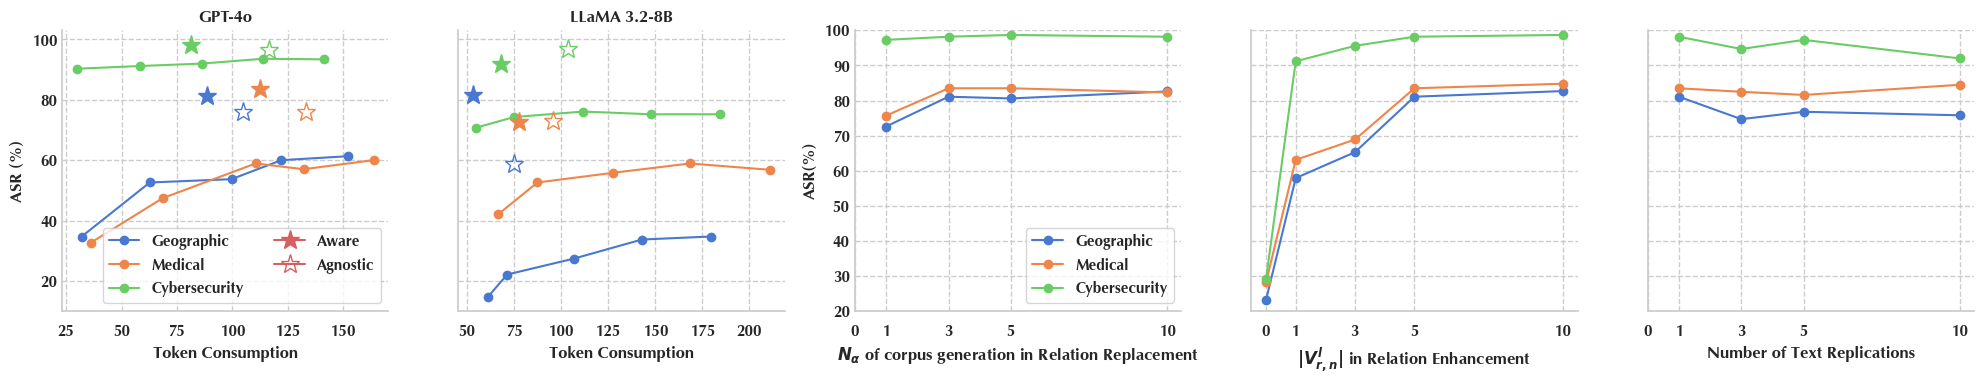

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set Seaborn style
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Optima'
plt.rcParams['font.weight'] = 'bold'

# Define colors
colors = sns.color_palette("muted")

# Data for the first set of plots
data_default = {
    'geographic': [(32, 34.7), (62.7, 52.6), (99.6, 53.7), (122.1, 60), (152.1, 61.3)],
    'medical': [(36, 32.6), (68.5, 47.4), (110.5, 58.9), (132.1, 57), (163.7, 60)],
    'cybersecurity': [(29.8, 90.3), (58.5, 91.2), (86.2, 92.0), (113.8, 93.6), (141.3, 93.4)],
    'gray': [(88.4, 81.1), (112.6, 83.5), (81.1, 98.2)],
    'black': [(104.7, 76.1), (133, 75.8), (116.5, 96.4)]
}

data_llama = {
    'geographic': [(61.1, 14.7), (71.3, 22.1), (106.9, 27.4), (142.9, 33.7), (179.7, 34.7)],
    'medical': [(66.6, 42.1), (87.4, 52.6), (127.5, 55.8), (168.4, 58.9), (210.9, 56.8)],
    'cybersecurity': [(54.9, 70.8), (75.1, 74.3), (111.6, 76.1), (147.8, 75.2), (184.5, 75.2)],
    'gray': [(53.3, 81.7), (77.8, 72.7), (68, 92)],
    'black': [(74.8, 58.7), (95.6 , 72.9), (103.8, 96.9)]
}

# Data for the second set of plots
x = [0, 1, 3, 5, 10]

data1 = [[[1, 72.6], [3, 81.1], [5, 80.6], [10, 82.6]],
         [[1, 75.7], [3, 83.5], [5, 83.5], [10, 82.3]],
         [[1, 97.3], [3, 98.2], [5, 98.7], [10, 98.2]]]

data3 = [[[0, 23.2], [1, 57.9], [3, 65.3], [5, 81.1], [10, 82.7]],
         [[0, 28.2], [1, 63.1], [3, 68.9], [5, 83.5], [10, 84.8]],
         [[0, 29.2], [1, 91.2], [3, 95.6], [5, 98.2], [10, 98.7]]]

data4 = [[[1, 81.1], [3, 74.7], [5, 76.8], [10, 75.8]],
         [[1, 83.5], [3, 82.5], [5, 81.6], [10, 84.5]],
         [[1, 98.2], [3, 94.7], [5, 97.3], [10, 92.0]]]

data_full = [data1, data3, data4]

# Create a figure with five subplots
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

# Plot for the default and llama models
for ax, (model_name, data) in zip(axes[:2], [('GPT-4o', data_default), ('LLaMA 3.2-8B', data_llama)]):
    for i, (dataset, points) in enumerate(data.items()):
        if dataset == 'gray':
            for j, baseline_point in enumerate(points):
                ax.plot(baseline_point[0], baseline_point[1], marker='*', color=colors[j], markersize=14)
            ax.plot([], [], marker='*', color=colors[3], markersize=14, label='Aware')
        elif dataset == 'black':
            for j, baseline_point in enumerate(points):
                ax.plot(baseline_point[0], baseline_point[1], marker='*', markerfacecolor='none', color=colors[j], markersize=14)
            ax.plot([], [], marker='*', color=colors[3], markerfacecolor='none', markersize=14, label='Agnostic')
        else:
            ax.plot([p[0] for p in points], [p[1] for p in points], marker='o', color=colors[i], label=dataset.capitalize())

    ax.set_title(model_name, fontweight='bold')
    ax.set_xlabel('Token Consumption', fontweight='bold')
    ax.grid(True, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.tick_params(axis='y', length=0)

axes[0].set_ylabel('ASR (%)', fontweight='bold')
axes[0].legend(ncol=2)

# Set y-limits for the first two subplots
for ax in axes[:2]:
    ax.set_ylim(10, 103)  # Adjust this range as needed
    # ax.set_xlim(25, 220)  # Adjust this range as needed

# Plot for the ablation study
x_labels = [
    r'$N_\alpha$ of corpus generation in Relation Replacement',
    r'$|V_{r,n}^{l}|$ in Relation Enhancement',
    'Number of Text Replications'
]

x_tick_labels = [
    ['0', '1', '3', '5', '10'],
    ['0', '1', '3', '5', '10'],
    ['0', '1', '3', '5', '10'],
]

for i, ax in enumerate(axes[2:]):
    ax.plot([d[0] for d in data_full[i][0]], [d[1] for d in data_full[i][0]], marker='o', color=colors[0], label='Geographic')
    ax.plot([d[0] for d in data_full[i][1]], [d[1] for d in data_full[i][1]], marker='o', color=colors[1], label='Medical')
    ax.plot([d[0] for d in data_full[i][2]], [d[1] for d in data_full[i][2]], marker='o', color=colors[2], label='Cybersecurity')

    ax.set_xlabel(x_labels[i], fontweight='bold')
    if i == 0:
        ax.set_ylabel('ASR(%)', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(x_tick_labels[i])
    if i == 0:
        ax.legend(loc='lower right')
    ax.grid(True, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    
    ax.tick_params(axis='y', length=0)

# Set y-limits for the last three subplots
for ax in axes[2:]:
    ax.set_ylim(20, 100)  # Adjust this range as needed
# Hide y-tick labels for specific subplots
for ax in [axes[1], axes[3], axes[4]]:
    ax.set_yticklabels([])  # Hide y-tick labels

# Adjust layout
plt.tight_layout()
# plt.subplots_adjust(wspace=0.17)
plt.savefig('combined_plots.pdf')

# Show plot
plt.show()
